In [2]:
import pandas as pd
# Load dataset
df = pd.read_csv("../data/train.csv")
# Show first 5 rows
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
print(df.shape)

(159571, 8)


In [4]:
print(df.columns)

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')


In [5]:
print(df.isnull().sum())

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [6]:
print(df['toxic'].value_counts())

toxic
0    144277
1     15294
Name: count, dtype: int64


In [7]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [8]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [9]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{"needn't", 'which', 'hasn', 'at', 'ma', 'and', "i've", "it's", "shouldn't", 'has', "should've", 'or', "she's", 'was', 'wasn', "we'd", "hadn't", 're', "hasn't", "aren't", 'themselves', 'will', 'from', 'hadn', 'about', 'him', "she'll", 'who', 'i', 'only', 'theirs', 'isn', 'ourselves', "won't", 'yourself', 'having', 'off', 'shan', 'such', 'after', 'those', "mightn't", 'on', 'by', "they've", 'through', 'doing', 'ours', "you'd", "he'll", 'again', 'more', 'weren', 'what', "he's", "it'd", 'you', 'the', 'out', "shan't", 'couldn', 'during', 'few', 'herself', "it'll", 'll', "wasn't", 'aren', 'how', 'being', 'didn', 'all', "haven't", 'is', 'his', 's', 'these', 've', 'me', 'same', 'd', 'wouldn', 'now', 't', 'up', 'into', 'we', 'itself', "you'll", 'so', 'yourselves', 'where', "mustn't", 'with', 'yours', "weren't", 'against', 'an', 'needn', 'any', "i'd", 'but', 'until', "we've", "they're", 'if', "that'll", 'm', 'then', "isn't", 'am', 'once', 'been', 'should', 'some', 'because', 'o', "you've", 'than

In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    cleaned_text = " ".join(words)
    return cleaned_text

In [12]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [13]:
sample_text = "You are a VERY stupid person!!!"
print(clean_text(sample_text))

stupid person


In [14]:
df['cleaned_comment'] = df['comment_text'].apply(clean_text)

In [15]:
df[['comment_text', 'cleaned_comment']].head()

,comment_text,cleaned_comment
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,aww matches background colour seemingly stuck ...
2,"Hey man, I'm really not trying to edit war. It...",hey man really trying edit war guy constantly ...
3,"""\nMore\nI can't make any real suggestions on ...",make real suggestions improvement wondered sec...
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page


In [16]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

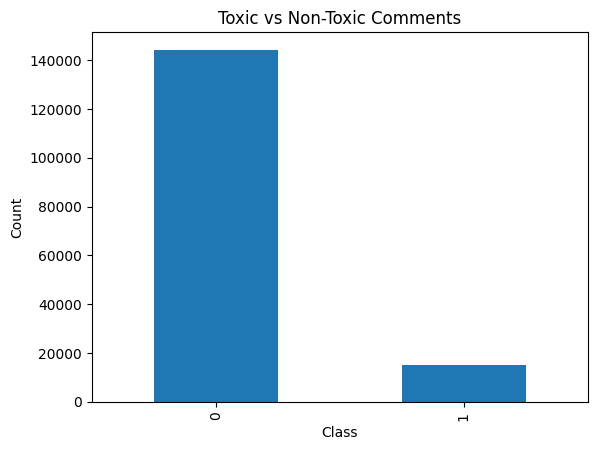

In [17]:
df['toxic'].value_counts().plot(kind='bar')
plt.title("Toxic vs Non-Toxic Comments")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

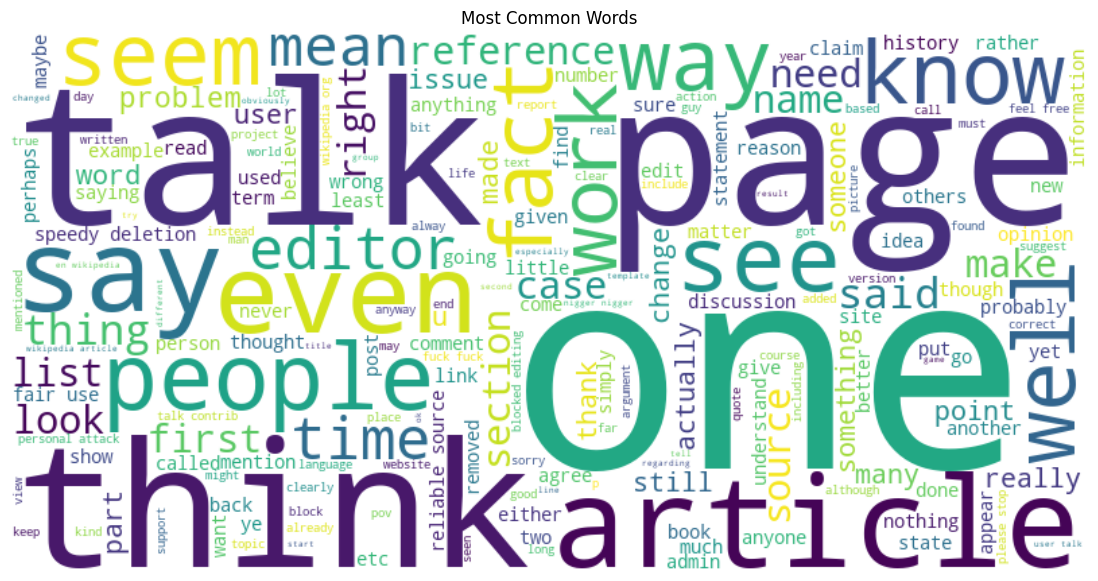

In [18]:
text = " ".join(df['cleaned_comment'])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words")
plt.show()

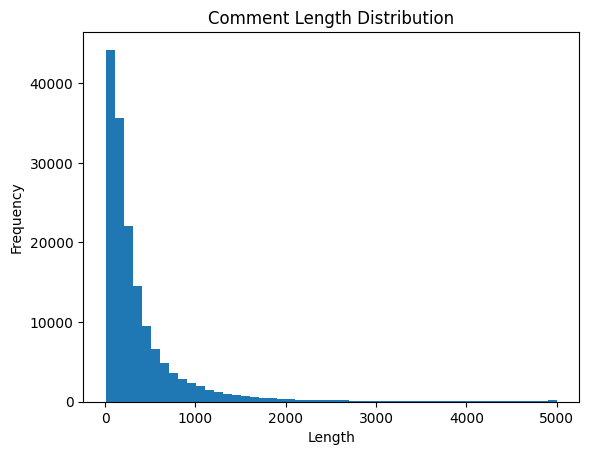

In [19]:
df['comment_length'] = df['comment_text'].apply(len)
plt.hist(df['comment_length'], bins=50)
plt.title("Comment Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [21]:
X = df['cleaned_comment']
y = df['toxic']

In [22]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
y_pred = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.957167476108413


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28859
           1       0.91      0.62      0.73      3056

    accuracy                           0.96     31915
   macro avg       0.93      0.80      0.86     31915
weighted avg       0.96      0.96      0.95     31915



In [29]:
sample = ["I love this project"]
sample_tfidf = tfidf.transform(sample)
prediction = model.predict(sample_tfidf)
print(prediction)

[0]


In [30]:
import pickle

In [31]:
with open("../models/toxicity_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [32]:
with open("../models/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)